# Utforske data


In [1]:
import os
import shutil
import kagglehub
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import random


/opt/anaconda3/envs/dat255/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SEED = 123

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [3]:
#Laster ned datasettet
dataset_path = kagglehub.dataset_download("mohamedhanyyy/chest-ctscan-images")
# Definerer hovedmappe for data
data_path = os.path.join(dataset_path, "Data")

#Lager paths til de forskjellige datasettene
train_path = os.path.join(data_path, "train")
valid_path = os.path.join(data_path, "valid")
test_path = os.path.join(data_path, "test")

#Se innholdet i mappene
print("Data path:", data_path)
print()
print("TRAIN:", os.listdir(train_path))
print("VALID:", os.listdir(valid_path))
print("TEST:", os.listdir(test_path))

Data path: /Users/christoffertoftevag/.cache/kagglehub/datasets/mohamedhanyyy/chest-ctscan-images/versions/1/Data

TRAIN: ['squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa', 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'normal', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa']
VALID: ['squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa', 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'normal', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa']
TEST: ['squamous.cell.carcinoma', 'large.cell.carcinoma', 'adenocarcinoma', 'normal']


### OBS

Datasettet er inkonsistent. Train og Valid har like navn, men Testsettet har en forkortelse på navnene.

In [4]:
# Definerer en fast og konsistent rekkefølge på klassene

long_class_names = [
    "adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib",
    "large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa",
    "normal",
    "squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa"
]

print(long_class_names)

['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']


In [5]:
#Mapper kort til langt navn slik at alle datasettene bruker likt navn!
test_to_train_name_map = {
    "adenocarcinoma": "adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib",
    "large.cell.carcinoma": "large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa",
    "normal": "normal",
    "squamous.cell.carcinoma": "squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa"
}

In [6]:
#lager path til ny mappe
test_fixed_path = os.path.join(data_path, "test_fixed")

#sletter mappen hvis den finnes fra før
if os.path.exists(test_fixed_path):
    shutil.rmtree(test_fixed_path)

#lager ny tom mappe
os.makedirs(test_fixed_path)


#looper gjennom mappingen vi lagde over
for short_name, long_name in test_to_train_name_map.items():
    #lager paths til source og destination
    src = os.path.join(test_path, short_name)
    dst = os.path.join(test_fixed_path, long_name)
    shutil.copytree(src, dst)

#nå skal alle dataene ha samme (lange) navn
print("Ny testnavn:", os.listdir(test_fixed_path))

Ny testnavn: ['squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa', 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'normal', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa']


In [7]:


img_size = (128, 128)
batch_size = 32


train_data = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels="inferred",
    #klassene blir tall
    label_mode="int",
    #slik at vi har full kontroll over rekkefølgen av klassene i alle datasettene
    class_names=long_class_names,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True,
    seed=SEED
)

valid_data = tf.keras.utils.image_dataset_from_directory(
    valid_path,
    labels="inferred",
    label_mode="int",
    class_names=long_class_names,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

test_data = tf.keras.utils.image_dataset_from_directory(
    test_fixed_path,
    labels="inferred",
    label_mode="int",
    class_names=long_class_names,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

Found 613 files belonging to 4 classes.
Found 72 files belonging to 4 classes.
Found 315 files belonging to 4 classes.


2026-04-13 19:08:51.475540: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-04-13 19:08:51.475584: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-04-13 19:08:51.475622: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-04-13 19:08:51.475646: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-13 19:08:51.475669: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [8]:
print("Train classes:", train_data.class_names)
print("Valid classes:", valid_data.class_names)
print("Test classes:", test_data.class_names)

Train classes: ['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']
Valid classes: ['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']
Test classes: ['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']


In [9]:
#gjør om pikselverdi fra 0-255 -> 0-1
#(modellen lærer mye bedre med små verdier!)
normalization_layer = tf.keras.layers.Rescaling(1.0 / 255)
#normaliser hvert bildet og behold label
train_data = train_data.map(lambda img, label: (normalization_layer(img), label))
valid_data = valid_data.map(lambda img, label: (normalization_layer(img), label))
test_data = test_data.map(lambda img, label: (normalization_layer(img), label))

In [58]:
train_data = train_data.prefetch(tf.data.AUTOTUNE)
valid_data = valid_data.prefetch(tf.data.AUTOTUNE)
test_data = test_data.prefetch(tf.data.AUTOTUNE)

In [11]:
for images, labels in train_data.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("First 10 labels:", labels[:10].numpy())

Image batch shape: (32, 128, 128, 3)
Label batch shape: (32,)
First 10 labels: [3 1 3 2 3 0 0 0 0 3]


2026-04-13 19:08:51.667066: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


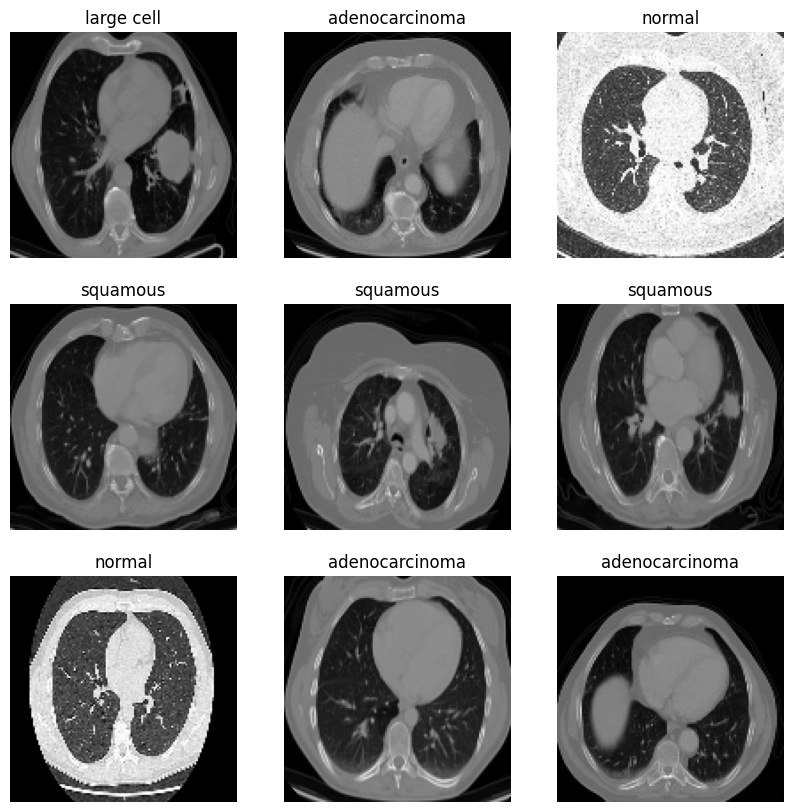

2026-04-13 19:08:52.073816: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [12]:
#navnene er veldig lange -> plottene ser dårlig ut
#lager forkortelser
display_names = [
    "adenocarcinoma",
    "large cell",
    "normal",
    "squamous"
]

plt.figure(figsize=(10, 10))

for images, labels in train_data.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(display_names[labels[i]])
        plt.axis("off")
    plt.show()

In [61]:
#vise klassefordeling
def count_images_per_class(folder_path):
    counts = {}
    for class_name in os.listdir(folder_path):
        class_folder = os.path.join(folder_path, class_name)
        if os.path.isdir(class_folder):
            counts[class_name] = len(os.listdir(class_folder))
    return counts

print("Train:", count_images_per_class(train_path))
print("Valid:", count_images_per_class(valid_path))
print("Test:", count_images_per_class(test_path))

Train: {'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 155, 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 195, 'normal': 148, 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': 115}
Valid: {'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 15, 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 23, 'normal': 13, 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': 21}
Test: {'squamous.cell.carcinoma': 90, 'large.cell.carcinoma': 51, 'adenocarcinoma': 120, 'normal': 54}


Modellering
--

Commonsense baseline
--

Vi ville ha en baseline modell som vi kan prøve å forbedre med mer avanserte modelle. Vi bruker en majoritetsklasse-modell som alltid predikerer den mest vanlige klassen i treningssettet. I koden over kan vi se at adenocarcinoma er den største klassen i treningsdata. I koden under kan vi se at adenocarcinoma er i index 0, vi kan bruke dette til å se hvilke accuracy vi kan få hvis vi kun tipper adenocarcinoma. Med denne "commonsense" modellen får vi en baseline på 38% accuracy.

In [16]:
print(class_names)

['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']


In [72]:
#model0
#over kan vi se at klasse 0 er adenocarcinoma.
majority_class = 0

labels_true = []

for img, label in test_data:
    labels_true.extend(label.numpy())

labels_true = np.array(labels_true)
labels_pred = np.full_like(labels_true, fill_value=majority_class)

print("Baseline accuracy:", accuracy_score(labels_true, labels_pred))
print(classification_report(labels_true, labels_pred, zero_division=0))
print(confusion_matrix(labels_true, labels_pred))

Baseline accuracy: 0.38095238095238093
              precision    recall  f1-score   support

           0       0.38      1.00      0.55       120
           1       0.00      0.00      0.00        51
           2       0.00      0.00      0.00        54
           3       0.00      0.00      0.00        90

    accuracy                           0.38       315
   macro avg       0.10      0.25      0.14       315
weighted avg       0.15      0.38      0.21       315

[[120   0   0   0]
 [ 51   0   0   0]
 [ 54   0   0   0]
 [ 90   0   0   0]]


2026-04-13 20:13:38.951886: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Simple dens layer neural network
--

In [18]:
#model1
ff_network = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128, 128, 3)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(4, activation="softmax")
])

ff_network.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     3,145,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,146,900 (12.00 MB)

 Trainable params: 3,146,900 (12.00 MB)

 Non-trainable params: 0 (0.00 B)

ff_network summaty:
--
flatten: gjør vår input 128 * 128 * 3 om til en lang liset med tall = 49152.
første dense laget: (input_features × neurons) + bias = 3,145,792
andre dense laget: 64 * 16 + 16 = 1,040
siste dense laget: 16 * 4 + 4 = 68

In [19]:
ff_network.compile(
    loss="sparse_categorical_crossentropy", 
    optimizer="adam",
    metrics=["accuracy"]
)

In [20]:
history_ff = ff_network.fit(
    train_data,
    validation_data=valid_data,
    epochs=10
)

Epoch 1/10


2026-04-13 19:08:52.996627: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.3719 - loss: 43.6447 - val_accuracy: 0.3611 - val_loss: 80.2913
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4584 - loss: 40.5665 - val_accuracy: 0.3889 - val_loss: 46.0072
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4878 - loss: 18.6281 - val_accuracy: 0.4167 - val_loss: 6.3574
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5546 - loss: 4.0545 - val_accuracy: 0.4444 - val_loss: 3.8775
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5922 - loss: 2.6967 - val_accuracy: 0.5694 - val_loss: 2.1262
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6117 - loss: 2.0064 - val_accuracy: 0.5972 - val_loss: 2.0710
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7243 - loss: 1.0118 - val_accuracy: 0.4861 - val_loss: 1.8209
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7080 - loss: 1.2254 - val_accuracy: 0.5139 - val_los

In [76]:
score = ff_network.evaluate(test_data, verbose=0)

print("loss:", score[0])
print("Accuracy of the model was {}%".format(score[1]*100))

loss: 2.600688934326172
Accuracy of the model was 39.047619700431824%


Vi kan tydlig se at modellen vår ikke er god nok. Vi kan videre undersøke hvordan modellen fungerer.

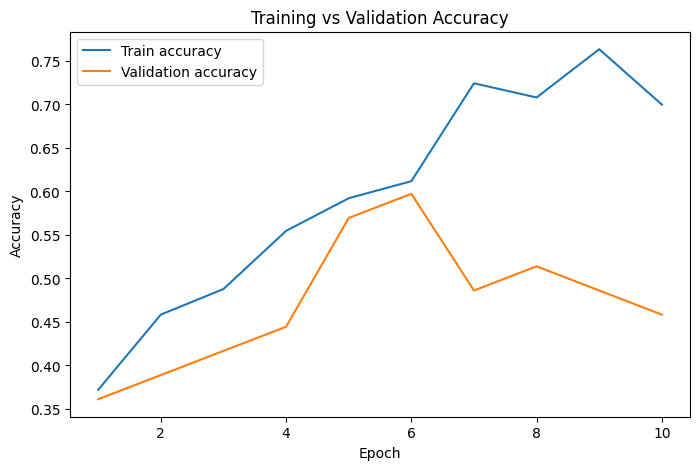

In [80]:
import matplotlib.pyplot as plt

train_acc = history_ff.history["accuracy"]
val_acc = history_ff.history["val_accuracy"]
train_loss = history_ff.history["loss"]
val_loss = history_ff.history["val_loss"]

epochs = range(1, len(train_acc) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc, label="Train accuracy")
plt.plot(epochs, val_acc, label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

Tolkning av graf
--


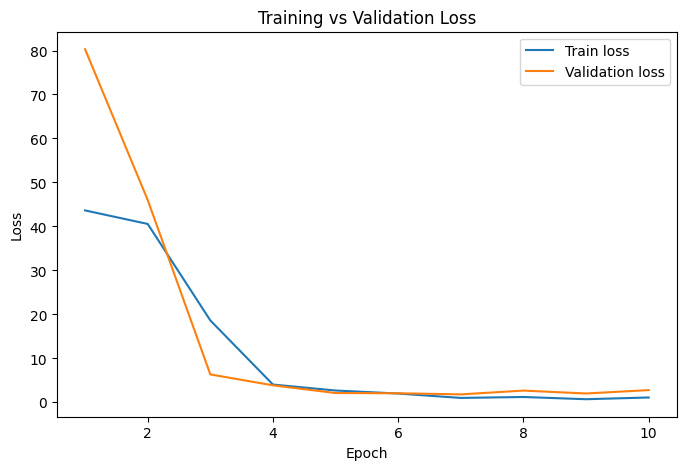

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, label="Train loss")
plt.plot(epochs, val_loss, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

Tolkning av graf
--
Modellen lærer veldig fort mellom epoche 1 - 3.
mellom epoche 2-4 ligger kruvene veldig nær hverandre. modellen generaliserer bra. 
Epoche 7-10 begynner validationloss å flate ut også stige litt. Trainingloss fortsetter ganske flatt, dette kan tyde på overfitting.

2026-04-13 19:08:58.799478: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


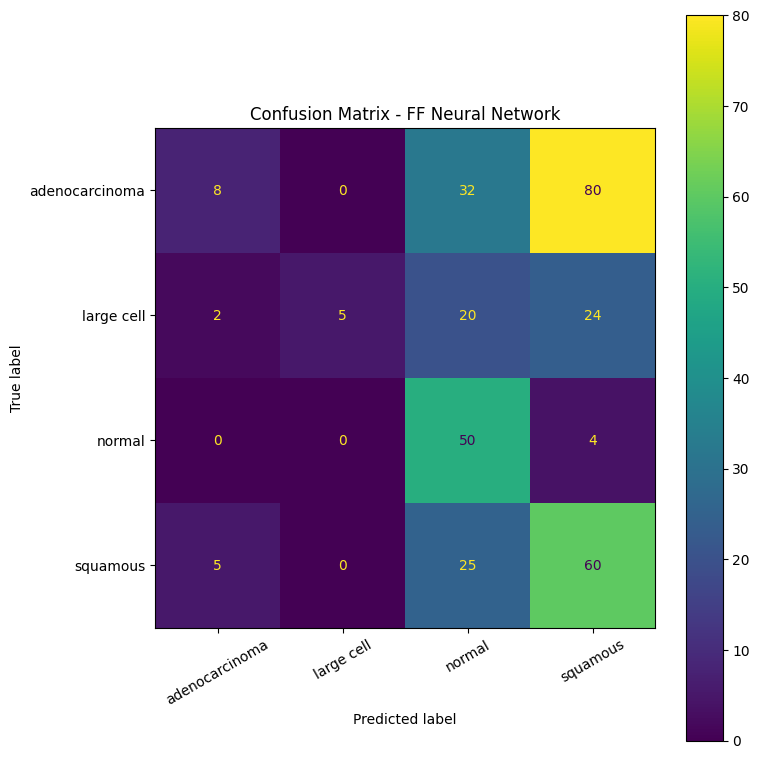

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

y_true = []
y_pred = []

for images, labels in test_data:
    predictions = ff_network.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

cm = confusion_matrix(y_true, y_pred)

# Korte navn her også
display_names = [
    "adenocarcinoma",
    "large cell",
    "normal",
    "squamous"
]

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_names)
disp.plot(ax=ax, cmap="viridis", xticks_rotation=30, colorbar=True)

plt.title("Confusion Matrix - FF Neural Network")
plt.tight_layout()
plt.show()

Tolkning av Confusion Matrix
--
Modellen hadde totalt 8+5+50+60 = 123 riktige predikasjoner av totalt 310 observasjoner. Dette betyr en accuracy på 123/310 = 40%, dette bekrefter at modellen presterer svakt sammenlignet med vår baseline på 38%.

Ved nærmere analyse av confusion matrixen ser vi tydlige svakheter i klassifiseringen av enkelte klasser. Spesielt gjelder dette adenocarcinoma, hvor modellen kun klassifiserte 8 riktige av 120 tilfeller, og 80 tilfeller ble klassifisert som squamous og 32 som normal. Detter viser at modellen i litne grad klarer å skille adenocarcinoma fra de andre klassene.

Modellen klarer i nesten alle tilfeller å predikerer normal, med 50 riktige av 54 tillfeller, og modellen gjøre det relativt greit på aquamous med 60 riktige. Dette tyder på en skjevhet (bias) i modellen hvor den har en tendens til å velge disse klassene.

En slik bias er spesielt problematisk i en medisinsk kontekst, hvor det innebærer at kreftseller blir i noen tilfeller klassifisert som normal

Vi kan se om datasettet kan være en av grunnene for at modellen gjør det så dårlig:

In [25]:
print("Train:", count_images_per_class(train_path))
print("Valid:", count_images_per_class(valid_path))
print("Test:", count_images_per_class(test_path))

Train: {'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 155, 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 195, 'normal': 148, 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': 115}
Valid: {'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 15, 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 23, 'normal': 13, 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': 21}
Test: {'squamous.cell.carcinoma': 90, 'large.cell.carcinoma': 51, 'adenocarcinoma': 120, 'normal': 54}


Vi kan tydlig se at large cell er den klassen med minst treningssamples. Dette kan forklare grunnen for at modellen ikke klarer å lære gode mønstre for denne klassen. 
Samtidig ser vi at testsettet inneholder 120 tilfeller av adenocarcinoma, men modellen klarer kun å klassifisere 8 riktig. Dette kan tyde på at datasettet ikke er det eneste problemet, men at modellen ikke klarer å fange opp mønstre i dataen. Dette er forventet i en feedforward modell som ser bilder som en flatten liste med tall.

Data agumentation and rescaling
--
Vi kan prøve å fikse problemet med lite data ved hjelp av agumentation:

In [26]:
#model2

data_augmentation_ff = tf.keras.Sequential([
    #tf.keras.layers.RandomFlip("horizontal"),
    #tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1)
])

# Enkel dense-modell med augmentation
ff_network_aug = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128, 128, 3)),

    data_augmentation_ff,

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(4, activation="softmax")
])


ff_network_aug.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │     3,145,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,146,900 (12.00 MB)

 Trainable params: 3,146,900 (12.00 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
ff_network_aug.compile(
    loss="sparse_categorical_crossentropy", 
    optimizer="adam",
    metrics=["accuracy"]
)

In [28]:
history_ff_aug = ff_network_aug.fit(
    train_data,
    validation_data=valid_data,
    epochs=10
)

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.2773 - loss: 69.0873 - val_accuracy: 0.3611 - val_loss: 31.4723
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.2855 - loss: 78.8554 - val_accuracy: 0.1250 - val_loss: 18.0249
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.3083 - loss: 78.4535 - val_accuracy: 0.3750 - val_loss: 30.8516
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.2871 - loss: 76.3069 - val_accuracy: 0.4028 - val_loss: 12.0262
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.3116 - loss: 72.2922 - val_accuracy: 0.3333 - val_loss: 23.1827
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.3181 - loss: 67.6235 - val_accuracy: 0.3750 - val_loss: 26.9517
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.3263 - loss: 61.4511 - val_accuracy: 0.4167 - val_loss: 27.1409
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.3295 - loss: 57.7068 - val_accur

In [29]:
score = ff_network_aug.evaluate(test_data, verbose=0)

print("Test loss:", score[0])
print("Test accuracy:", score[1])

Test loss: 19.847431182861328
Test accuracy: 0.4920634925365448


Konklusjon av FFNN:
--
Med omfattende testing og analyse ser vi at resultatene fra FFNN-modelen ikke er pålitlige nok til å kunne trekke en konklusjon. Modellen er for enkel, og datasettet er for lite til at modellen kunne lære mønstre. Vi observerte også stor variasjon (+- 15%) mellom kjøring av samme kode på forskjellige seed, noe som tyder på at en mer avanser modell må tas i bruk.

Prøver en CNN modell
--

In [30]:
#model3
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128,128,3)),

    tf.keras.layers.Conv2D(32, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(4, activation="softmax")
])

In [31]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,764 (397.52 KB)

 Trainable params: 101,764 (397.52 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
history_cnn = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=15,
)

Epoch 1/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.2822 - loss: 1.3556 - val_accuracy: 0.1806 - val_loss: 1.3630
Epoch 2/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.2594 - loss: 1.2972 - val_accuracy: 0.2778 - val_loss: 1.2663
Epoch 3/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.4502 - loss: 1.2181 - val_accuracy: 0.5000 - val_loss: 1.1839
Epoch 4/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.4927 - loss: 1.1207 - val_accuracy: 0.4861 - val_loss: 1.0947
Epoch 5/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.5041 - loss: 1.0749 - val_accuracy: 0.5000 - val_loss: 1.0176
Epoch 6/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.5139 - loss: 1.0874 - val_accuracy: 0.4861 - val_loss: 1.0591
Epoch 7/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.5318 - loss: 1.0131 - val_accuracy: 0.5000 - val_loss: 1.0415
Epoch 8/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.5057 - loss: 1.0402 - val_accuracy: 0.5000 - v

In [33]:
test_loss, test_acc = model.evaluate(test_data, verbose=0)

print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

Test loss: 0.9605829119682312
Test accuracy: 0.5428571701049805


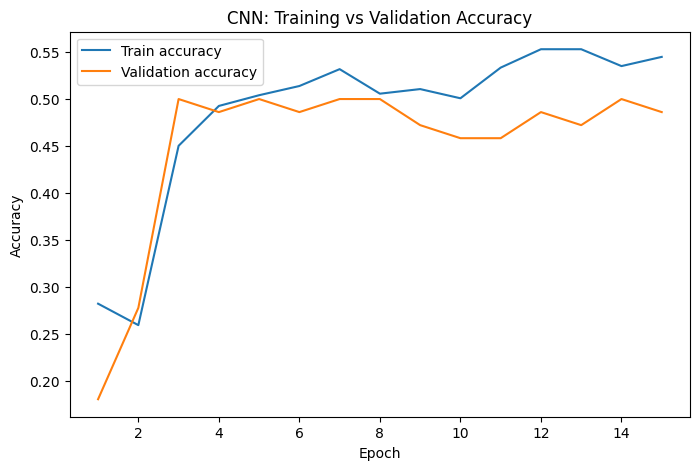

In [34]:
import matplotlib.pyplot as plt

train_acc = history_cnn.history["accuracy"]
val_acc = history_cnn.history["val_accuracy"]
train_loss = history_cnn.history["loss"]
val_loss = history_cnn.history["val_loss"]

epochs = range(1, len(train_acc) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc, label="Train accuracy")
plt.plot(epochs, val_acc, label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN: Training vs Validation Accuracy")
plt.legend()
plt.show()

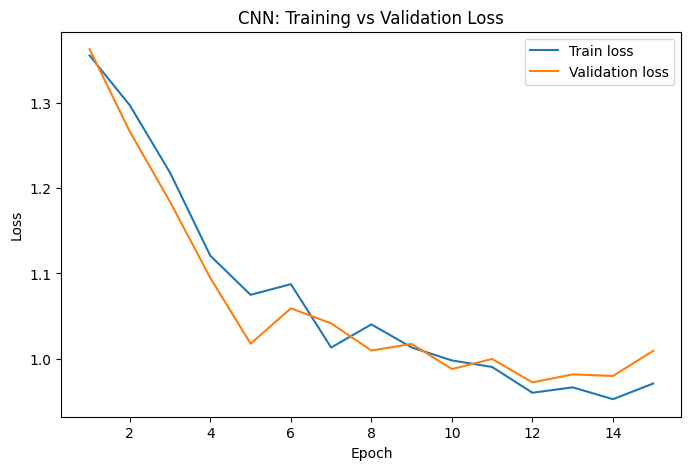

In [35]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, label="Train loss")
plt.plot(epochs, val_loss, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN: Training vs Validation Loss")
plt.legend()
plt.show()

Tolkning av graf
--
Train accuracy går opp, noe som viser at modellen lærer. modellen finner mønster i data. Modellen er robust, validation holder seg stabil. Vi ser ingen tegn til overfitting, og det er bra generelt, men vi vil først ha en modell som overfitter for å deretter endre modellen til at den ikke overfitter.

Vi kan endre modellen slik at den overfitter:

In [36]:
#model4
#vi lager en større modell og øker epokene:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128,128,3)),

    tf.keras.layers.Conv2D(64, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(256, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(4, activation="softmax")
])

In [37]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 404,228 (1.54 MB)

 Trainable params: 404,228 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
history_cnn = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=20,
)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - accuracy: 0.2594 - loss: 1.3566 - val_accuracy: 0.1806 - val_loss: 1.3746
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.3181 - loss: 1.2556 - val_accuracy: 0.2917 - val_loss: 1.2601
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.4502 - loss: 1.1712 - val_accuracy: 0.3750 - val_loss: 1.1585
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.4910 - loss: 1.0997 - val_accuracy: 0.4583 - val_loss: 1.0763
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.4894 - loss: 1.0934 - val_accuracy: 0.5000 - val_loss: 1.0581
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.4992 - loss: 1.0454 - val_accuracy: 0.4861 - val_loss: 1.0149
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.5090 - loss: 0.9952 - val_accuracy: 0.5000 - val_loss: 1.0082
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.5073 - loss: 1.0369 - val_accuracy: 0.4722 - v

In [39]:
test_loss, test_acc = model.evaluate(test_data, verbose=0)

print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

Test loss: 1.008546233177185
Test accuracy: 0.4317460358142853


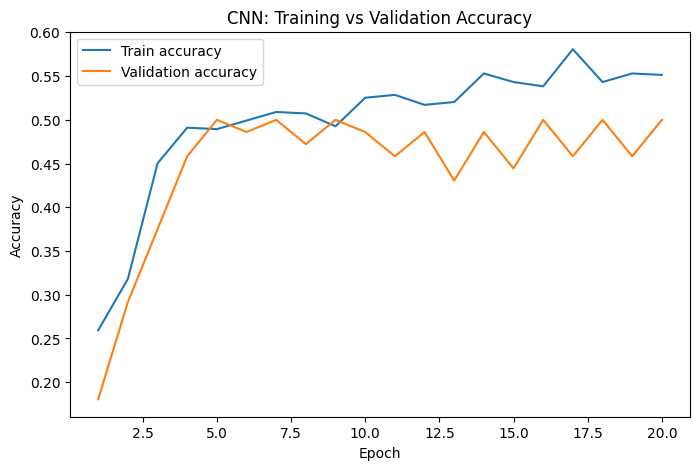

In [40]:
import matplotlib.pyplot as plt

train_acc = history_cnn.history["accuracy"]
val_acc = history_cnn.history["val_accuracy"]
train_loss = history_cnn.history["loss"]
val_loss = history_cnn.history["val_loss"]

epochs = range(1, len(train_acc) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc, label="Train accuracy")
plt.plot(epochs, val_acc, label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN: Training vs Validation Accuracy")
plt.legend()
plt.show()

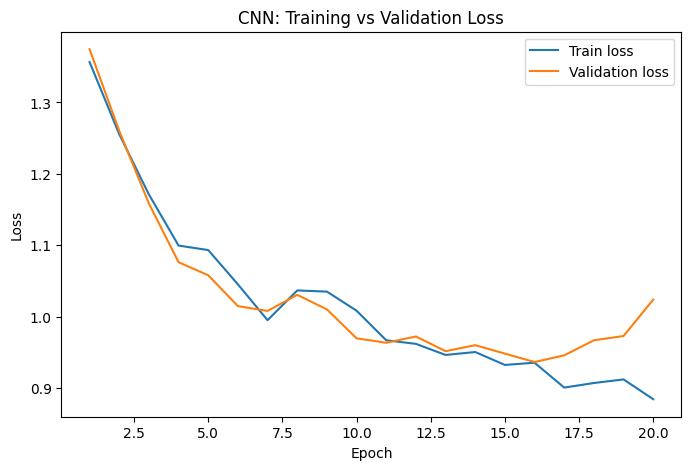

In [41]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, label="Train loss")
plt.plot(epochs, val_loss, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN: Training vs Validation Loss")
plt.legend()
plt.show()

Tolkning av graf
--
Vi kan se at traing accuract går jevnt opp, dette tyder på at modellen lærer. Train accuracy er er over validation accuracy store deler av epokene, noe som tyder på mild overfitting. dette er bra, det var det vi ville oppnå. Begge loss minker, men etter epoke 16 øker validation loss. Dette kan være et tegn på at overfitting begynner. Ut i fra det vi har tolket fra grafene, kan vi lage en forbedret modell

Forbedring:
Vi kan legge til data augmentation. Grafene viser at modellen lærte treningsdata bedre enne valideringsdata. det kan tyde på at modellen begynte å bli for god på treningssettet, da vil augmentation hjelpe med å modellen flere varianter av samme bilde, redusere overfitting og gjøre modellen mer robust. 
Modellen var ganske kraftig med 64 - 128 - 256, vi kan endre dette til 32 - 64 - 128. det er ingenting i grafene som tilsier at modellen er for krafig, så vi kan gjøre den litt mindre. Det vil da føre til at det blir lettere å generalisere på et lite datasett og reduserer overfitting. 
Vi kan legge til padding="same" for å bevare mer informasjon i feature maps.
Vi kan minke litt på dropout. 
Vi kan legge til early stopping. Grafene viser at validation accuracy flater ut ganske tidlig, og validation loss begynner å øke senere, dette tyder på at modellen er best før siste epoke, noe som vi kan fiske med early stopping, som vil stoppe treningen når modellen slutter å bli bedre.
Merk: vi kunne også lagt til cross-validation for å få en mer robust evaluering, men ble ikke brukt siden datasettet hadde en fast test/train/validation - inndeling.

In [42]:
#model5

data_augmentation = tf.keras.Sequential([
    #tf.keras.layers.RandomFlip("horizontal"),
    #tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
])

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128, 128, 3)),

    data_augmentation,

    tf.keras.layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(4, activation="softmax")
])

In [43]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [44]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

In [45]:
history_cnn = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=25,
    callbacks=[early_stopping]
)

model.summary()

Epoch 1/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.2268 - loss: 1.3663 - val_accuracy: 0.1806 - val_loss: 1.4238
Epoch 2/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.3132 - loss: 1.3191 - val_accuracy: 0.2917 - val_loss: 1.3417
Epoch 3/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.4144 - loss: 1.2470 - val_accuracy: 0.2778 - val_loss: 1.3302
Epoch 4/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.4551 - loss: 1.1713 - val_accuracy: 0.5000 - val_loss: 1.1163
Epoch 5/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.3768 - loss: 1.2886 - val_accuracy: 0.2222 - val_loss: 1.2944
Epoch 6/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.4486 - loss: 1.1904 - val_accuracy: 0.3750 - val_loss: 1.2247
Epoch 7/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.4992 - loss: 1.1059 - val_accuracy: 0.4722 - val_loss: 1.1767
Epoch 8/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.5090 - loss: 1.0506 - val_accuracy: 0.5139 - v

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_5 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305,294 (1.16 MB)

 Trainable params: 101,764 (397.52 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 203,530 (795.04 KB)

In [46]:
test_loss, test_acc = model.evaluate(test_data, verbose=0)

print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

Test loss: 0.9601412415504456
Test accuracy: 0.5365079641342163


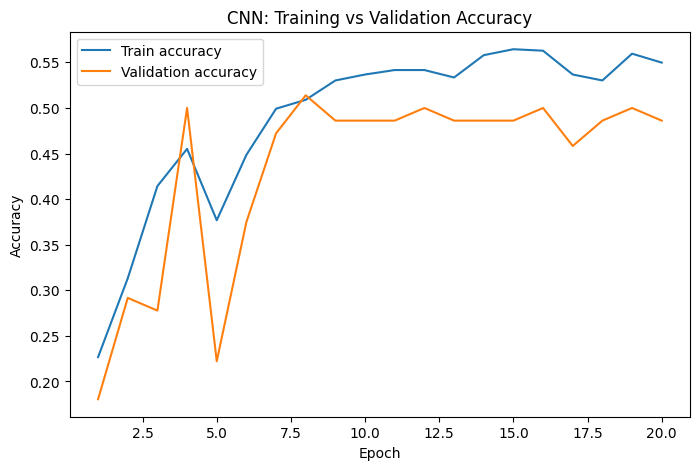

In [47]:
import matplotlib.pyplot as plt

train_acc = history_cnn.history["accuracy"]
val_acc = history_cnn.history["val_accuracy"]
train_loss = history_cnn.history["loss"]
val_loss = history_cnn.history["val_loss"]

epochs = range(1, len(train_acc) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc, label="Train accuracy")
plt.plot(epochs, val_acc, label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN: Training vs Validation Accuracy")
plt.legend()
plt.show()

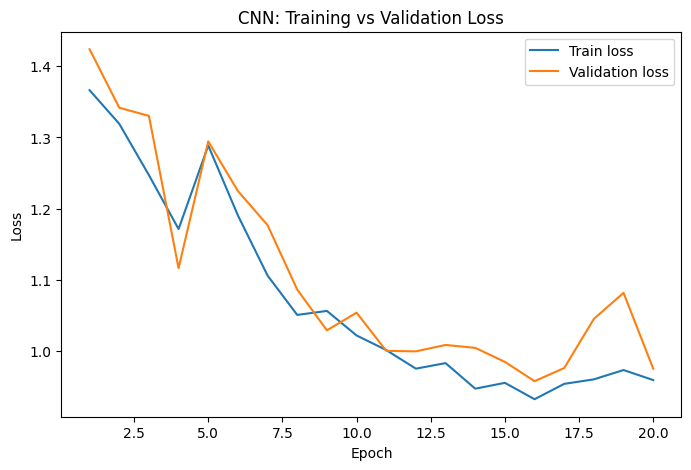

In [48]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, label="Train loss")
plt.plot(epochs, val_loss, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN: Training vs Validation Loss")
plt.legend()
plt.show()

2026-04-13 19:10:08.029521: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


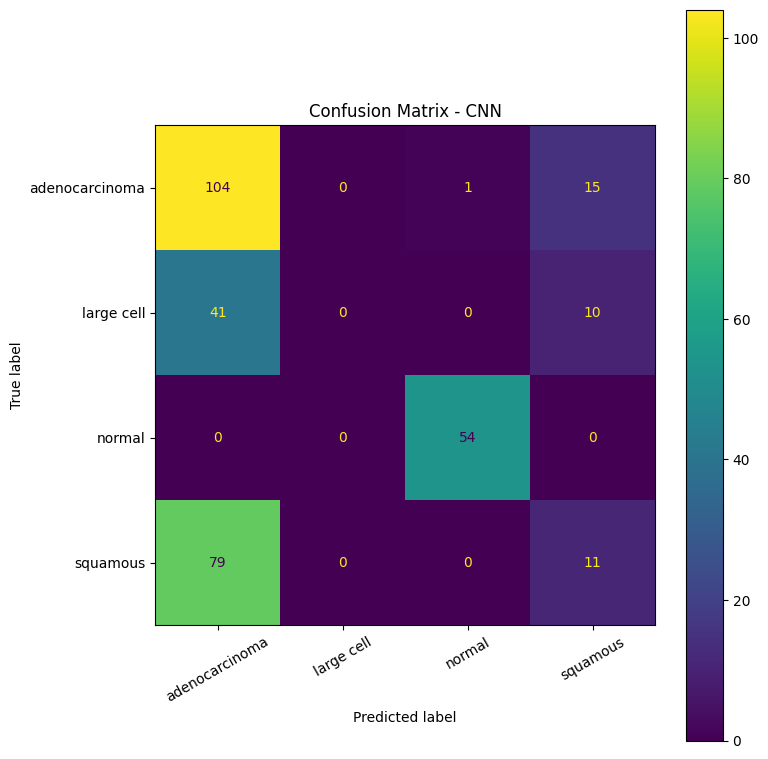

In [49]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

y_true = []
y_pred = []

for images, labels in test_data:
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

cm = confusion_matrix(y_true, y_pred)

display_names = [
    "adenocarcinoma",
    "large cell",
    "normal",
    "squamous"
]

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_names)
disp.plot(ax=ax, cmap="viridis", xticks_rotation=30, colorbar=True)

plt.title("Confusion Matrix - CNN")
plt.tight_layout()
plt.show()

Tolkning av Confusion Matrix
--
Confusion matrixen viser en tydelig skjevhet i predikasjonene, hvor nesten alle tilfellene klassifiseres som adenocarcinoma. Dette fører til at klasser som large cell og squamous nesten aldri blir riktig klassifisert.

Selv om denne modellen har fått klart høyes accuracy, skjuler dne et alvorlig problem hvor modellen ikke klarer å skille mellom flere av klassene. Dette viser at accuracy alene ikke er bra nok som evalueringsmetode.

Forbedring av modellen:
Confusion matrixen viste at modellen hadde en sterk bias mot adenocarcinoma, og at den i liten grad klarte å klassifisere riktig large cell og squamous. For å fikse dette kan vi legge til weights til klassene, slik at feil på underrepresenterte klasser ble straffet hardere under trening. I tillegg legger vi til batch og normalization for å stabilisere læringen og forbedre feature extraction. ReduceLROnPlateau og EarlyStopping brukt for å forbedre treningsstabilitet og generalisering


Transfer learning
--

In [53]:
# model5

data_augmentation_tl = tf.keras.Sequential([
    tf.keras.layers.RandomZoom(0.1)
])

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

pretrained_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128, 128, 3)),
    data_augmentation_tl,
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(4, activation="softmax")
])

pretrained_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

pretrained_model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_9 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,228 (8.93 MB)

 Trainable params: 82,244 (321.27 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [54]:
history_pretrained = pretrained_model.fit(
    train_data,
    validation_data=valid_data,
    epochs=20
)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 203ms/step - accuracy: 0.4095 - loss: 1.8716 - val_accuracy: 0.4861 - val_loss: 1.2895
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.5188 - loss: 1.3694 - val_accuracy: 0.4583 - val_loss: 1.2465
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.5710 - loss: 1.2923 - val_accuracy: 0.4583 - val_loss: 1.2569
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.5579 - loss: 1.2643 - val_accuracy: 0.4583 - val_loss: 1.4774
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.6166 - loss: 1.0897 - val_accuracy: 0.5278 - val_loss: 1.5799
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.6346 - loss: 1.1945 - val_accuracy: 0.4861 - val_loss: 1.4269
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.6542 - loss: 1.0800 - val_accuracy: 0.4722 - val_loss: 1.3397
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.6852 - loss: 0.9277 - val_accuracy: 0.5972 - 

In [55]:
score = pretrained_model.evaluate(test_data, verbose=0)

print("Test loss:", score[0])
print("Test accuracy:", score[1])

Test loss: 0.7522199153900146
Test accuracy: 0.7015873193740845


2026-04-13 19:10:56.183862: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


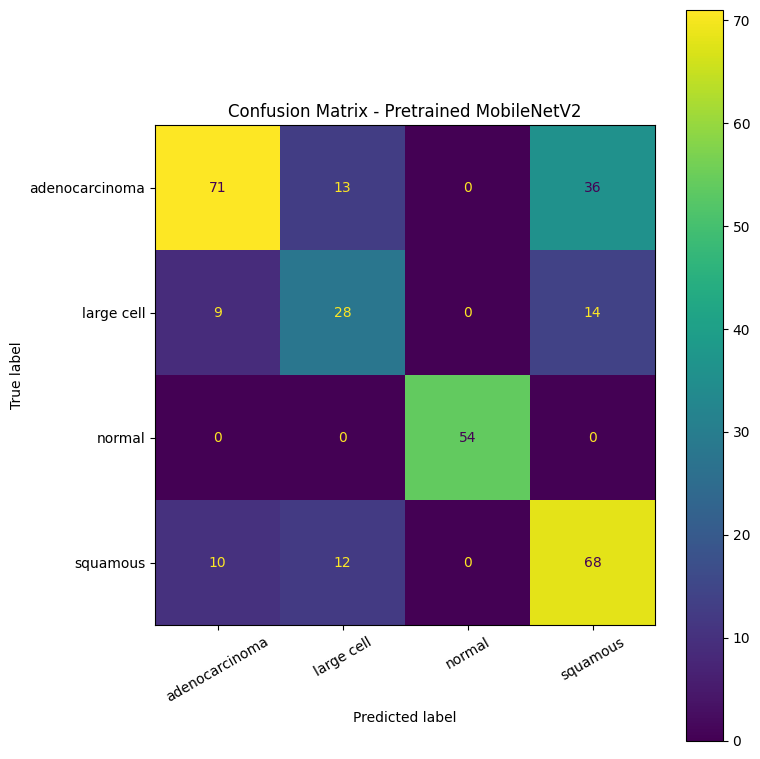

In [56]:
y_true = []
y_pred = []

for images, labels in test_data:
    predictions = pretrained_model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_names)
disp.plot(ax=ax, cmap="viridis", xticks_rotation=30, colorbar=True)

plt.title("Confusion Matrix - Pretrained MobileNetV2")
plt.tight_layout()
plt.show()